In [1]:
from logging_module import setup_logging
from typing import TypedDict, NotRequired
from langgraph.graph import StateGraph

logger = setup_logging()
logger.info("logging initialized")

2026-05-28T09:05:52.309023Z [info     ] logging initialized           


In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    final: NotRequired[str]

In [3]:
def first_node(state: AgentState) -> AgentState:
    """First Node of the sequence"""
    state["final"] = f"Hi {state['name']}"
    return state


def second_node(state: AgentState) -> AgentState:
    """Second Node of the sequence"""
    state["final"] = f"You are {state['age']}"
    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")
app = graph.compile()

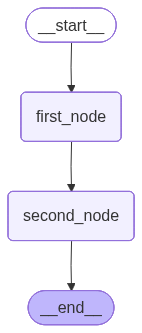

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"name": "Sree", "age": 30})

In [7]:
result

{'name': 'Sree', 'age': 30, 'final': 'You are 30'}

In [ ]:
from typing import List


class AgentState3(TypedDict):
    name: str
    age: int
    skills: List[str]
    final: str

In [9]:
def first_node_1(state: AgentState3) -> AgentState3:
    """First Node of the sequence"""
    state["final"] = f"Hi {state['name']}"
    return state


def second_node_1(state: AgentState3) -> AgentState3:
    """Second Node of the sequence"""
    state["final"] = state["final"] + f", You are {state['age']}. "
    return state


def third_node_1(state: AgentState3) -> AgentState3:
    """Third Node of the sequence"""
    state["final"] = state["final"] + f"You have skills in {", ".join(state['skills'])}"
    return state

In [10]:
graph_1 = StateGraph(AgentState3)

graph_1.add_node("first_node", first_node_1)
graph_1.add_node("second_node", second_node_1)
graph_1.add_node("third_node", third_node_1)

graph_1.set_entry_point("first_node")
graph_1.add_edge("first_node", "second_node")
graph_1.add_edge("second_node", "third_node")
graph_1.set_finish_point("third_node")
app_1 = graph_1.compile()

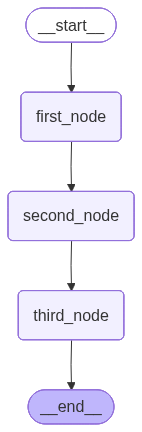

In [11]:
from IPython.display import Image, display

display(Image(app_1.get_graph().draw_mermaid_png()))

In [ ]:
result = app_1.invoke(
    {"name": "Sree", "age": 30, "skills": ["Python", "JS"], "final": ""}
)

In [13]:
result

{'name': 'Sree',
 'age': 30,
 'skills': ['Python', 'JS'],
 'final': 'Hi Sree, You are 30. You have skills in Python, JS'}